# Import Important Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns 
import plotly.express as px


# Import Dataset

In [2]:
df = pd.read_csv("student-scores.csv")

In [3]:
df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


# Exploratory Data Analysis

In [4]:
# the shape of dataframe
df.shape

(2000, 17)

In [5]:
df.dtypes

id                            int64
first_name                      str
last_name                       str
email                           str
gender                          str
part_time_job                  bool
absence_days                  int64
extracurricular_activities     bool
weekly_self_study_hours       int64
career_aspiration               str
math_score                    int64
history_score                 int64
physics_score                 int64
chemistry_score               int64
biology_score                 int64
english_score                 int64
geography_score               int64
dtype: object

In [6]:
# information about data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          2000 non-null   int64
 1   first_name                  2000 non-null   str  
 2   last_name                   2000 non-null   str  
 3   email                       2000 non-null   str  
 4   gender                      2000 non-null   str  
 5   part_time_job               2000 non-null   bool 
 6   absence_days                2000 non-null   int64
 7   extracurricular_activities  2000 non-null   bool 
 8   weekly_self_study_hours     2000 non-null   int64
 9   career_aspiration           2000 non-null   str  
 10  math_score                  2000 non-null   int64
 11  history_score               2000 non-null   int64
 12  physics_score               2000 non-null   int64
 13  chemistry_score             2000 non-null   int64
 14  biology_score      

In [7]:
# statistic calculation
df.describe()

,id,absence_days,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,1000.500000,3.665500,17.755500,83.452000,80.332000,81.336500,79.995000,79.58150,81.277500,80.888000
std,577.494589,2.629271,12.129604,13.224906,12.736046,12.539453,12.777895,13.72219,12.027087,11.637705
min,1.000000,0.000000,0.000000,40.000000,50.000000,50.000000,50.000000,30.00000,50.000000,60.000000
25%,500.750000,2.000000,5.000000,77.000000,69.750000,71.000000,69.000000,69.00000,72.000000,71.000000
50%,1000.500000,3.000000,18.000000,87.000000,82.000000,83.000000,81.000000,81.00000,83.000000,81.000000
75%,1500.250000,5.000000,28.000000,93.000000,91.000000,92.000000,91.000000,91.00000,91.000000,91.000000
max,2000.000000,10.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,99.000000,100.000000


In [8]:
# check if there null values
df.isnull().sum()

id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

<Axes: xlabel='gender', ylabel='count'>

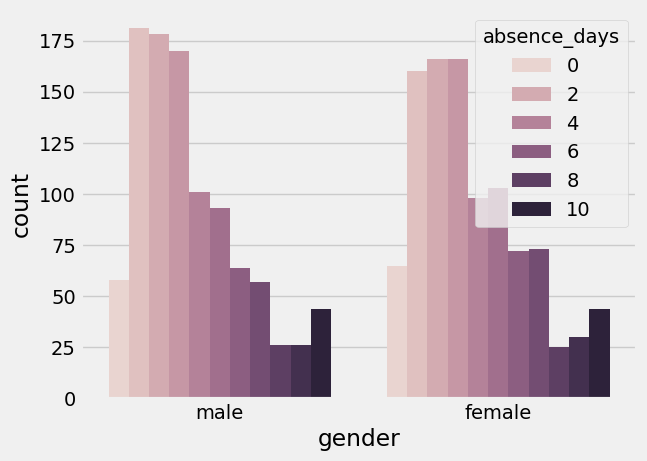

In [9]:
# distribution between gender and absence day
plt.style.use('fivethirtyeight') 
sns.countplot(data = df, x = "gender", hue = "absence_days")


<Axes: xlabel='Count', ylabel='career_aspiration'>

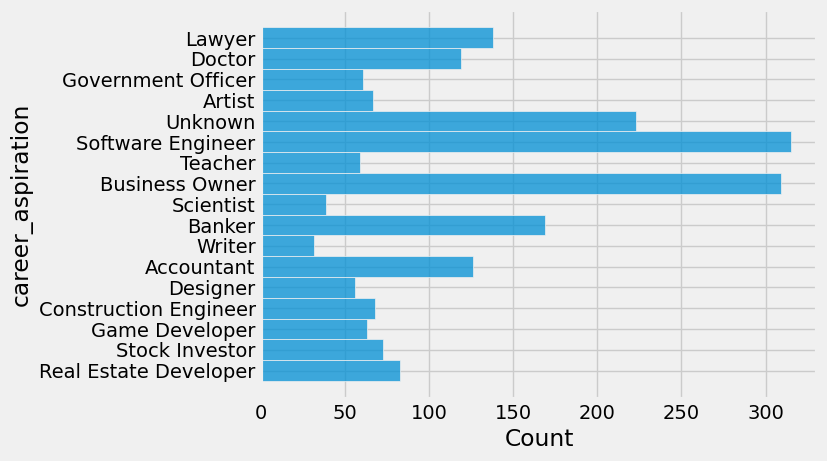

In [10]:
# distribution of career_aspiration
sns.histplot(data = df, y = "career_aspiration")

In [11]:
# Create new columns (Total, Average, Grade)
total = []
for i in range(df.shape[0]):
    total.append(df.iloc[i,10:17].sum())
df["total_score"] = total
df["total_score"].head()

0    574
1    640
2    605
3    551
4    521
Name: total_score, dtype: int64

<Axes: xlabel='first_name'>

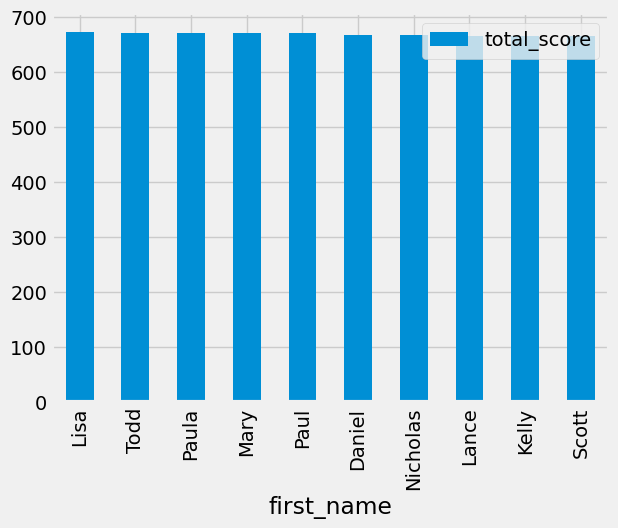

In [12]:
# plot of top 10 students
plot = df[["first_name","total_score"]].sort_values(by = "total_score",ascending = False).head(10)
plot.set_index("first_name").plot.bar()

In [13]:
# Create new columns (Total, Average, Grade)

average = []
for i in range(df.shape[0]):
    average.append(df.iloc[i,10:17].mean())
df["average_score"] = average
df["average_score"]

0       82.000000
1       91.428571
2       86.428571
3       78.714286
4       74.428571
          ...    
1995    79.714286
1996    76.285714
1997    82.571429
1998    80.857143
1999    88.142857
Name: average_score, Length: 2000, dtype: float64

<Axes: xlabel='average_score', ylabel='Count'>

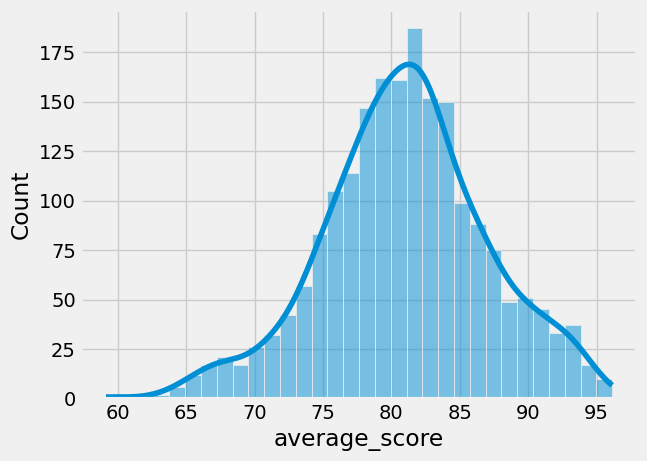

In [14]:
# distribution of average_score by seaborn
sns.histplot(x = df["average_score"], kde = True)

In [15]:
# Create new columns (Total, Average, Grade)

x = 0
grade = []
while x < df.shape[0]:
    if df.iloc[x,-1] > 90:
        grade.append("S") 
    elif df.iloc[x,-1] > 80:
        grade.append("A")
    elif df.iloc[x,-1] > 70:
        grade.append("B")
    elif df.iloc[x,-1] > 60:
        grade.append("C")
    elif df.iloc[x,-1] > 50:
        grade.append("D")
    else:
        grade.append("F")
    x += 1
df["grade"] = grade

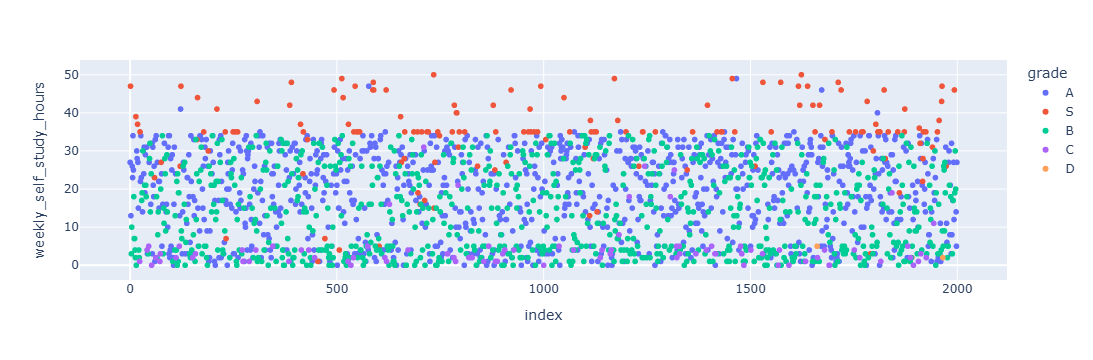

In [16]:
# distribution of grade by plotlyaverage_score
px.scatter(df,y = "weekly_self_study_hours", color = "grade")

<Axes: >

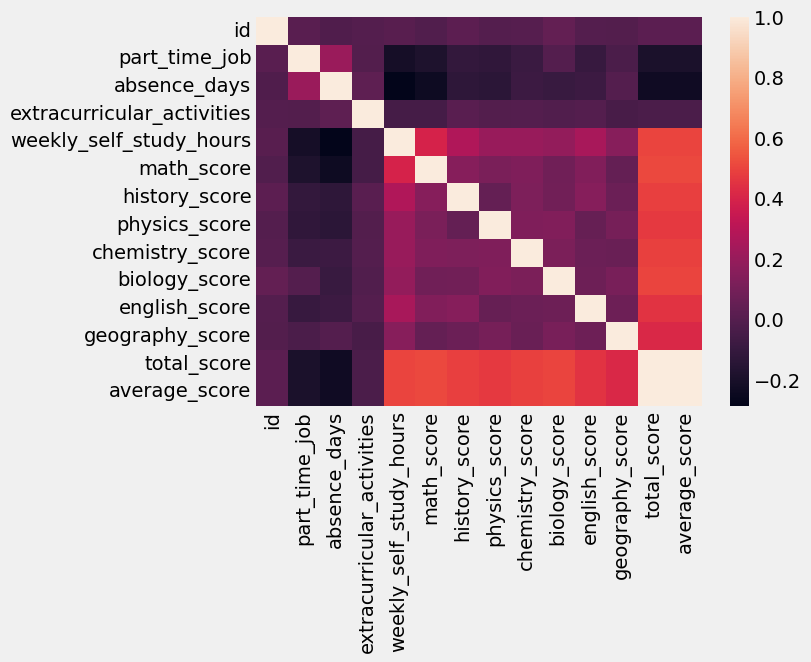

In [17]:
# calcilate correlation 
sns.heatmap(df.corr(numeric_only = True))

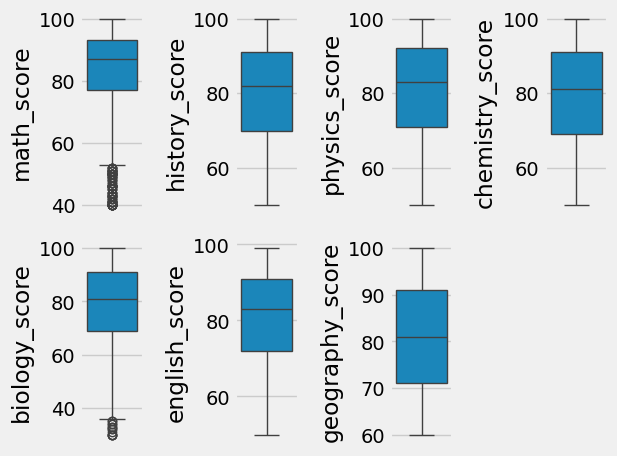

In [18]:
# boxplot per subject 
def plotting(plot, num):
    plt.subplot(2,4,num)
    sns.boxplot(df[plot])

plotting("math_score", 1)
plotting("history_score", 2)
plotting("physics_score", 3)
plotting("chemistry_score", 4)
plotting("biology_score", 5)
plotting("english_score", 6)
plotting("geography_score", 7)
plt.tight_layout()

In [19]:
df.columns

Index(['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job',
       'absence_days', 'extracurricular_activities', 'weekly_self_study_hours',
       'career_aspiration', 'math_score', 'history_score', 'physics_score',
       'chemistry_score', 'biology_score', 'english_score', 'geography_score',
       'total_score', 'average_score', 'grade'],
      dtype='str')

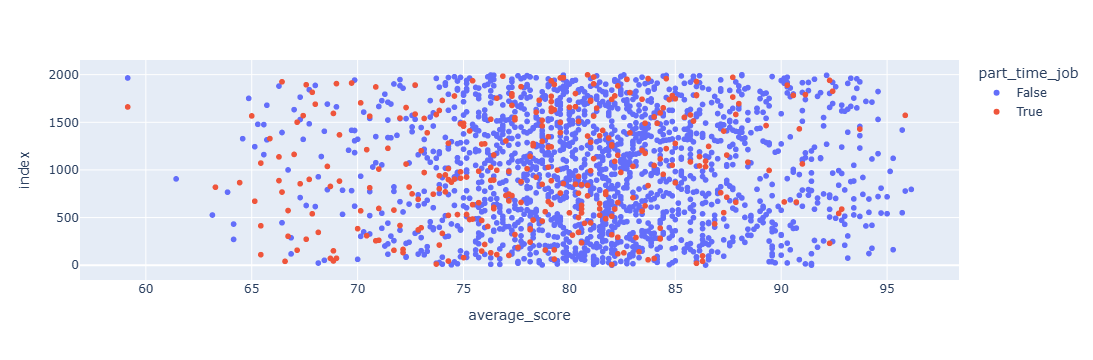

In [20]:
# distribution between part_time_job and average_score
px.scatter(df,x = "average_score", color = "part_time_job")


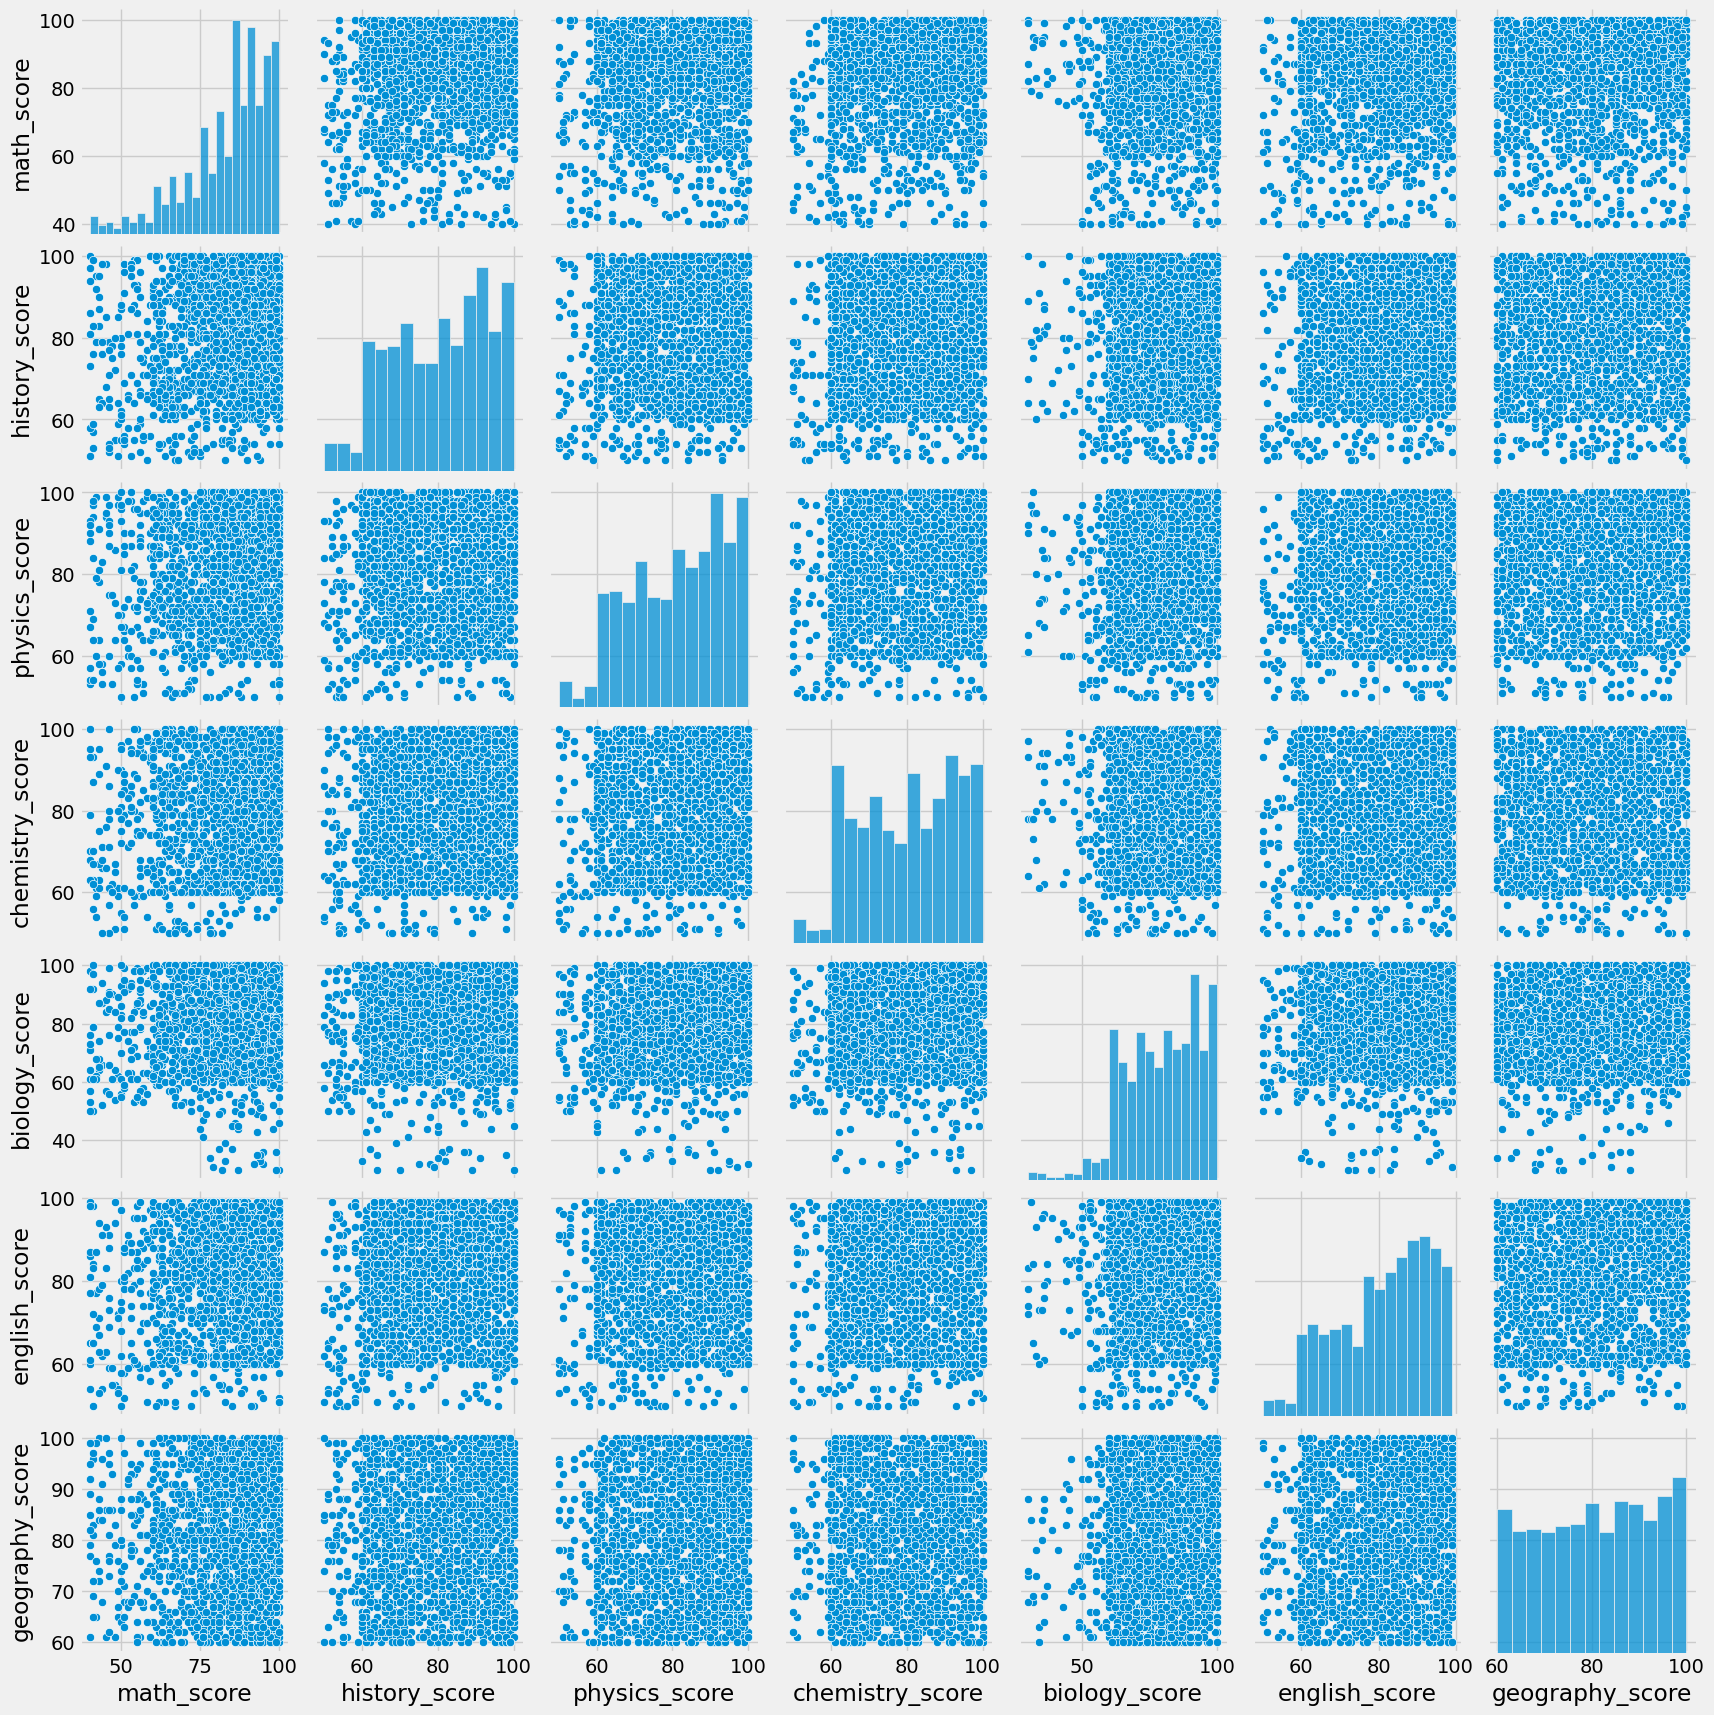

In [21]:
# relationship all subjects
x = df[['math_score', 'history_score', 'physics_score',
       'chemistry_score', 'biology_score', 'english_score', 'geography_score']]
sns.pairplot(x)

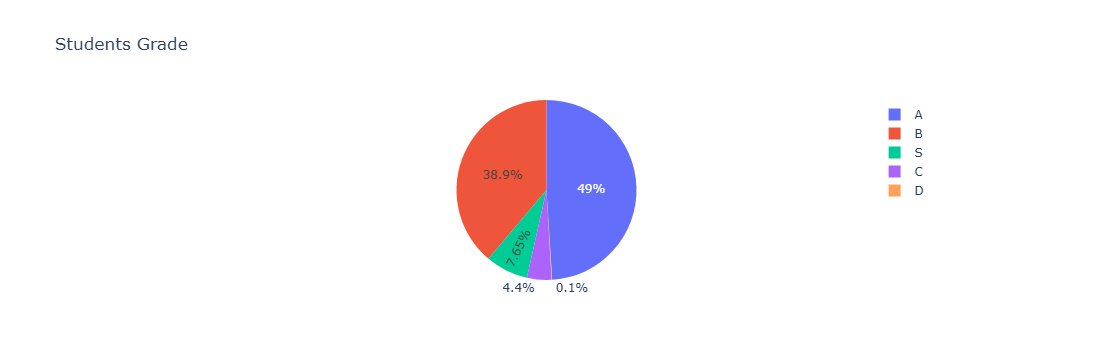

In [22]:
# distribution grade
px.pie(df,names = "grade", title="Students Grade")

# Conclusion

The students dataset student perform best score in all subject but there part time jobs effects score and mostly 49% students got A grade in exam aṇd 0.1% students S grade and no one is fail.
The average score of mostly students is 82% and mostly students career aspiration software engineer, businees owner, banker and lawyer but 220 students unknown what we dose.

THANK YOU